## LST-HW2024 — Band averaging + NDVI, NDWI, moving windows
- Promedia bandas B3, B4, B5 y ST_B10 de dos fechas (LC08 y LC09)
- Guarda los promedios como `bX_mean.tif`
- Procesa LST: crop, transformación K→°C, clipping
- Calcula NDVI y NDWI sobre las bandas promediadas
- Aplica moving windows y correlaciones con LST

### Libraries and general paths

In [19]:
import os
import rasterio
from rasterio.mask import mask
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import convolve

In [97]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'
lst_hw_dir = os.path.join(base_dir, 'LST-HW2024')
city_boundary = 'cba_boundary.gpkg'

# LC08 scene (25-01-24)
lc08 = 'LC08_L2SP_229082_20240125_20240130_02_T1'
# LC09 scene (02-02-24)
lc09 = 'LC09_L2SP_229082_20240202_20240205_02_T1'

# parameters for ndvi and ndwi classification
ndvi_dense_min = 0.29
ndvi_mid_min   = 0.22
ndwi_true_min  = 0.1

In [49]:
# Input band paths — two dates for each band
bands = {
    'B3':   [os.path.join(lst_hw_dir, f'{lc08}_SR_B3.TIF'),
             os.path.join(lst_hw_dir, f'{lc09}_SR_B3.TIF')],
    'B4':   [os.path.join(lst_hw_dir, f'{lc08}_SR_B4.TIF'),
             os.path.join(lst_hw_dir, f'{lc09}_SR_B4.TIF')],
    'B5':   [os.path.join(lst_hw_dir, f'{lc08}_SR_B5.TIF'),
             os.path.join(lst_hw_dir, f'{lc09}_SR_B5.TIF')],
    'B10':  [os.path.join(lst_hw_dir, f'{lc08}_ST_B10.TIF'),
             os.path.join(lst_hw_dir, f'{lc09}_ST_B10.TIF')],
}

# Output folders
means_dir          = os.path.join(lst_hw_dir, 'means')
output_folder_ndvi = os.path.join(lst_hw_dir, 'land-cover/ndvi')
output_folder_ndwi = os.path.join(lst_hw_dir, 'land-cover/ndwi')
output_folder_mw   = os.path.join(lst_hw_dir, 'land-cover/moving-windows')
output_folder_mw_ndvi = os.path.join(output_folder_mw, 'ndvi')
output_folder_mw_ndwi = os.path.join(output_folder_mw, 'ndwi')

for d in [means_dir, output_folder_ndvi, output_folder_ndwi,
          output_folder_mw_ndvi, output_folder_mw_ndwi]:
    os.makedirs(d, exist_ok=True)

# Derived paths — mean rasters
b3_mean_path  = os.path.join(means_dir, 'b3_mean.tif')
b4_mean_path  = os.path.join(means_dir, 'b4_mean.tif')
b5_mean_path  = os.path.join(means_dir, 'b5_mean.tif')
b10_mean_path = os.path.join(means_dir, 'b10_mean.tif')

# LST processed paths
lst_cropped_path = os.path.join(lst_hw_dir, 'LST_cropped_celsius.tif')
lst_clipped_path = os.path.join(lst_hw_dir, 'LST_clipped_celsius.tif')

# Indexes
ndvi_path     = os.path.join(output_folder_ndvi, 'ndvi.tif')
ndwi_path     = os.path.join(output_folder_ndwi, 'ndwi.tif')
ndvi_1_path   = os.path.join(output_folder_ndvi, 'ndvi_1.tif')
ndvi_0p5_path = os.path.join(output_folder_ndvi, 'ndvi_0p5.tif')
ndwi_1_path   = os.path.join(output_folder_ndwi, 'ndwi_1.tif')

# Boundary
bound = os.path.join(base_dir, 'vectors/', city_boundary)

### Step 1 — Average bands across two dates

In [22]:
def crop_to_boundary(path, gdf):
    """Crop a raster to the city boundary and return array + meta."""
    with rasterio.open(path) as src:
        gdf_r = gdf.to_crs(src.crs)
        arr, transform = mask(src, gdf_r.geometry, crop=True)
        arr = arr[0].astype('float32')
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        meta = src.meta.copy()
        meta.update(dtype='float32', nodata=np.nan,
                    height=arr.shape[0], width=arr.shape[1],
                    transform=transform)
    return arr, meta


def average_two_rasters(path1, path2, out_path, gdf):
    """Crop both rasters to boundary, then average pixel-wise."""
    arr1, meta = crop_to_boundary(path1, gdf)
    arr2, _    = crop_to_boundary(path2, gdf)

    # Si aún difieren por 1 pixel, recortamos al mínimo común
    min_rows = min(arr1.shape[0], arr2.shape[0])
    min_cols = min(arr1.shape[1], arr2.shape[1])
    arr1 = arr1[:min_rows, :min_cols]
    arr2 = arr2[:min_rows, :min_cols]

    mean_arr = np.nanmean(np.stack([arr1, arr2], axis=0), axis=0)

    meta.update(height=min_rows, width=min_cols)
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(mean_arr, 1)
    print(f'Saved: {out_path}')


# Cargar boundary primero
gdf = gpd.read_file(bound)

average_two_rasters(bands['B3'][0],  bands['B3'][1],  b3_mean_path,  gdf)
average_two_rasters(bands['B4'][0],  bands['B4'][1],  b4_mean_path,  gdf)
average_two_rasters(bands['B5'][0],  bands['B5'][1],  b5_mean_path,  gdf)
average_two_rasters(bands['B10'][0], bands['B10'][1], b10_mean_path, gdf)

C:\Users\guada\AppData\Local\Temp\ipykernel_29776\221864415.py:28: RuntimeWarning: Mean of empty slice
  mean_arr = np.nanmean(np.stack([arr1, arr2], axis=0), axis=0)
C:\Users\guada\AppData\Local\Temp\ipykernel_29776\221864415.py:28: RuntimeWarning: Mean of empty slice
  mean_arr = np.nanmean(np.stack([arr1, arr2], axis=0), axis=0)


Saved: ../../../datos-notebooks/3.global-data-cba/LST-HW2024\means\b3_mean.tif
Saved: ../../../datos-notebooks/3.global-data-cba/LST-HW2024\means\b4_mean.tif


C:\Users\guada\AppData\Local\Temp\ipykernel_29776\221864415.py:28: RuntimeWarning: Mean of empty slice
  mean_arr = np.nanmean(np.stack([arr1, arr2], axis=0), axis=0)


Saved: ../../../datos-notebooks/3.global-data-cba/LST-HW2024\means\b5_mean.tif
Saved: ../../../datos-notebooks/3.global-data-cba/LST-HW2024\means\b10_mean.tif


C:\Users\guada\AppData\Local\Temp\ipykernel_29776\221864415.py:28: RuntimeWarning: Mean of empty slice
  mean_arr = np.nanmean(np.stack([arr1, arr2], axis=0), axis=0)


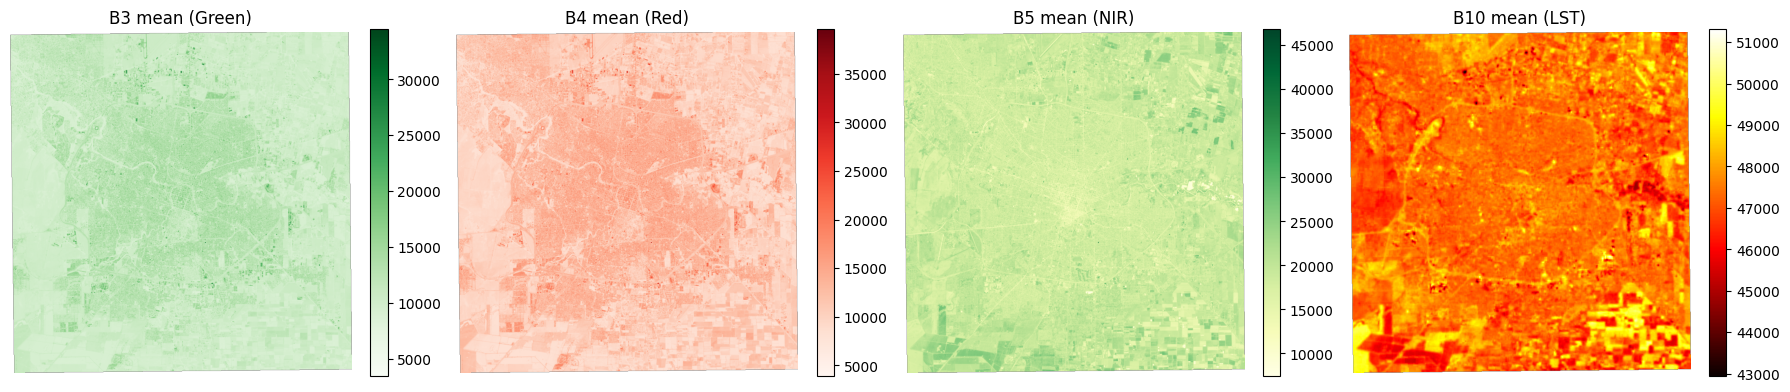

In [23]:
# Quick visual check of mean bands
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
for ax, (path, title, cmap) in zip(axs, [
    (b3_mean_path,  'B3 mean (Green)', 'Greens'),
    (b4_mean_path,  'B4 mean (Red)',   'Reds'),
    (b5_mean_path,  'B5 mean (NIR)',   'YlGn'),
    (b10_mean_path, 'B10 mean (LST)',  'hot'),
]):
    with rasterio.open(path) as src:
        data = src.read(1)
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### Step 2 — Crop and transform LST (K → °C)

In [53]:
# Crop to city boundary + K→°C conversion
with rasterio.open(b10_mean_path) as src_lst:
    lst_crs   = src_lst.crs
    gdf_lst   = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop  = lst_crop[0].astype(float) * 0.00341802 - 124.15
    lst_crop[lst_crop < 0] = np.nan  # nodata becomes -124.15 after transform

with rasterio.open(
    lst_cropped_path, 'w',
    driver='GTiff',
    height=lst_crop.shape[0], width=lst_crop.shape[1],
    count=1, dtype=lst_crop.dtype,
    crs=lst_crs, transform=lst_transform,
) as dst:
    dst.write(lst_crop, 1)

print('LST cropped saved.')

LST cropped saved.


In [52]:
# Clip LST to city polygon (nodata outside boundary)
with rasterio.open(lst_cropped_path) as src:
    boundary_crs = gdf.to_crs(src.crs)
    geoms = [boundary_crs.geometry.union_all().__geo_interface__]

    clipped_arr, clipped_transform = mask(src, geoms, crop=True, nodata=np.nan)
    clipped_arr = clipped_arr.astype('float32')
    if src.nodata is not None:
        clipped_arr[clipped_arr == src.nodata] = np.nan
    clipped_arr = clipped_arr.squeeze()

    meta = src.meta.copy()
    meta.update({
        'height': clipped_arr.shape[0],
        'width':  clipped_arr.shape[1],
        'transform': clipped_transform,
        'dtype': 'float32',
        'nodata': np.nan
    })

with rasterio.open(lst_clipped_path, 'w', **meta) as dst:
    dst.write(clipped_arr, 1)

print('LST clipped saved.')

LST clipped saved.


In [55]:
gdf = gpd.read_file(bound)

with rasterio.open(lst_clipped_path) as src:
    gdf= gdf.to_crs(src.crs)

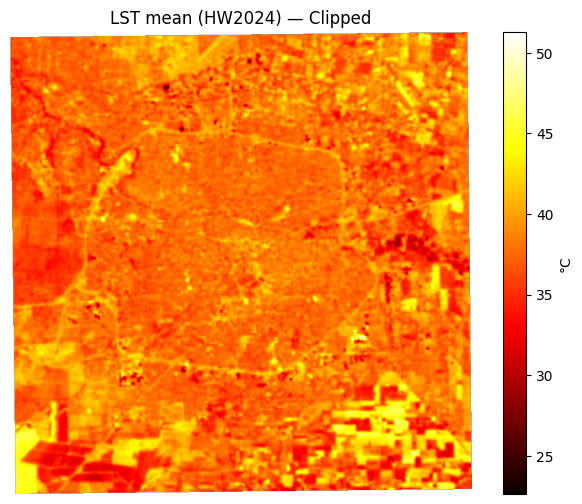

In [56]:
with rasterio.open(lst_clipped_path) as src:
    lst_plot = src.read(1)

plt.figure(figsize=(8, 6))
plt.imshow(lst_plot, cmap='hot')
plt.colorbar(label='°C')
plt.title('LST mean (HW2024) — Clipped')
plt.axis('off')
plt.show()

### Step 3 — Crop SR bands to LST extent and compute NDVI, NDWI

In [57]:
# Get LST extent geometry for cropping SR bands
with rasterio.open(lst_cropped_path) as lst_src:
    lst_bounds = lst_src.bounds
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype='float32', count=1, nodata=np.nan)

lst_geom = [{
    'type': 'Polygon',
    'coordinates': [[
        (lst_bounds.left,  lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.top),
        (lst_bounds.right, lst_bounds.top),
        (lst_bounds.right, lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.bottom)
    ]]
}]

In [35]:
def crop_band(path, geom):
    """Crop band to LST extent."""
    with rasterio.open(path) as src:
        data, _ = mask(src, geom, crop=True)
        return data[0].astype('float32')

green = crop_band(b3_mean_path, lst_geom)
red   = crop_band(b4_mean_path, lst_geom)
nir   = crop_band(b5_mean_path, lst_geom)

np.seterr(divide='ignore', invalid='ignore')

ndvi = (nir - red)   / (nir + red)
ndwi = (green - nir) / (green + nir)

with rasterio.open(ndvi_path, 'w', **out_meta) as dst:
    dst.write(ndvi.astype('float32'), 1)

with rasterio.open(ndwi_path, 'w', **out_meta) as dst:
    dst.write(ndwi.astype('float32'), 1)

print('NDVI and NDWI saved.')

NDVI and NDWI saved.


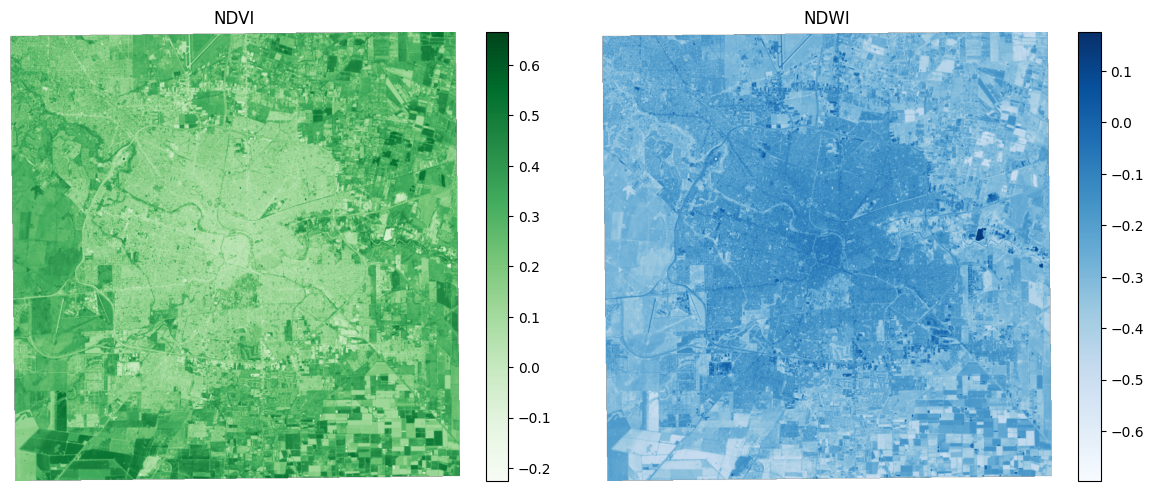

In [26]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im1 = axs[0].imshow(ndvi, cmap='Greens')
axs[0].set_title('NDVI')
axs[0].axis('off')
plt.colorbar(im1, ax=axs[0], fraction=0.046)

im2 = axs[1].imshow(ndwi, cmap='Blues')
axs[1].set_title('NDWI')
axs[1].axis('off')
plt.colorbar(im2, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()

### Step 5 — Classify NDVI and NDWI

In [99]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

ndvi_1   = np.where(ndvi > ndvi_dense_min, 1, 0).astype('float32')
ndvi_0p5 = np.where((ndvi > ndvi_mid_min) & (ndvi <= ndvi_dense_min), 1, 0).astype('float32')
ndwi_1   = np.where(ndwi > ndwi_true_min, 1, 0).astype('float32')

with rasterio.open(lst_cropped_path) as lst_src:
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(ndvi_1_path,   'w', **out_meta) as dst: dst.write(ndvi_1,   1)
with rasterio.open(ndvi_0p5_path, 'w', **out_meta) as dst: dst.write(ndvi_0p5, 1)
with rasterio.open(ndwi_1_path,   'w', **out_meta) as dst: dst.write(ndwi_1,   1)

print('Classified rasters saved.')

Classified rasters saved.


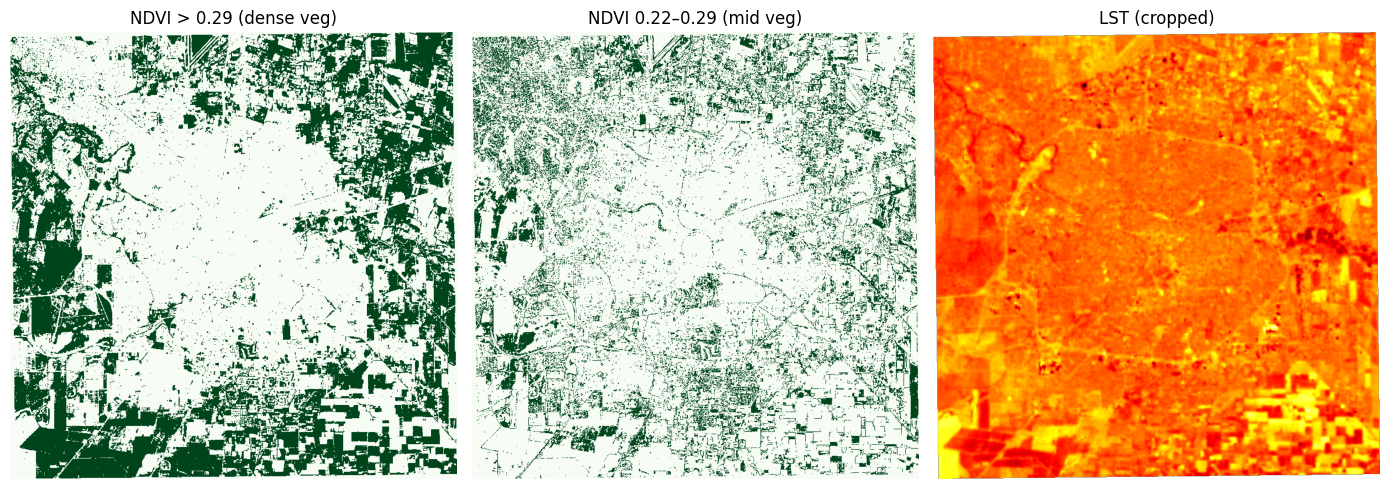

In [100]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

axs[0].imshow(ndvi_1,   cmap='Greens')
axs[0].set_title(f'NDVI > {ndvi_dense_min} (dense veg)')
axs[0].axis('off')

axs[1].imshow(ndvi_0p5, cmap='Greens')
axs[1].set_title(f'NDVI {ndvi_mid_min}–{ndvi_dense_min} (mid veg)')
axs[1].axis('off')

axs[2].imshow(lst_crop,   cmap='hot')
axs[2].set_title(f'LST (cropped)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

### Step 6 — Moving windows (distance-weighted Gaussian kernel)

In [88]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, 'Window size must be odd'
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()
    return weights


def moving_window_weighted(array, kernel):
    """Apply distance-weighted convolution."""
    return convolve(array, kernel, mode='nearest')

In [101]:
# NDVI moving windows
ndvi_paths = {
    'class_1':   ndvi_1_path,
    'class_0p5': ndvi_0p5_path,
}

for class_name, path in ndvi_paths.items():
    with rasterio.open(path) as src:
        data    = src.read(1).astype(np.float32)
        profile = src.profile

    for window_size in range(1, 101, 2):
        kernel   = distance_weighted_kernel(window_size)
        smoothed = moving_window_weighted(data, kernel)

        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(output_folder_mw_ndvi, f'{class_name}_window{window_size}.tif')

        with rasterio.open(out_path, 'w', **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)

    print(f'NDVI moving windows done: {class_name}')

NDVI moving windows done: class_1
NDVI moving windows done: class_0p5


In [17]:
# NDWI moving windows
with rasterio.open(ndwi_1_path) as src:
    data    = src.read(1).astype(np.float32)
    profile = src.profile

for window_size in range(1, 101, 2):
    kernel   = distance_weighted_kernel(window_size)
    smoothed = moving_window_weighted(data, kernel)

    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    out_path = os.path.join(output_folder_mw_ndwi, f'class_1_window{window_size}.tif')

    with rasterio.open(out_path, 'w', **out_profile) as dst:
        dst.write(smoothed.astype(np.float32), 1)

print('NDWI moving windows done.')

NDWI moving windows done.


### Step 7 — Correlations with LST

In [76]:
window_sizes = range(1, 101, 2)

with rasterio.open(lst_clipped_path) as lst:
    lst_crs       = lst.crs
    lst_clip      = lst.read(1)
    lst_transform = lst.transform

#### NDVI – LST

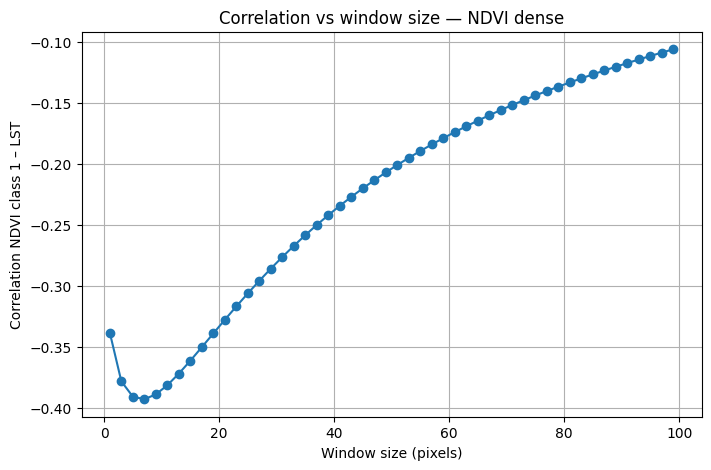

In [102]:
# Class 1 — dense vegetation
correlations = []

for w in window_sizes:
    ndvi_mw_path = os.path.join(output_folder_mw_ndvi, f'class_1_window{w}.tif')
    with rasterio.open(ndvi_mw_path) as src:
        ndvi_crop, _ = mask(src, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    valid_mask = ~np.isnan(lst_clip)
    corr = np.corrcoef(ndvi_crop[valid_mask], lst_clip[valid_mask])[0, 1]
    correlations.append(corr)

plt.figure(figsize=(8, 5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel('Window size (pixels)')
plt.ylabel('Correlation NDVI class 1 – LST')
plt.title('Correlation vs window size — NDVI dense')
plt.grid(True)
plt.show()

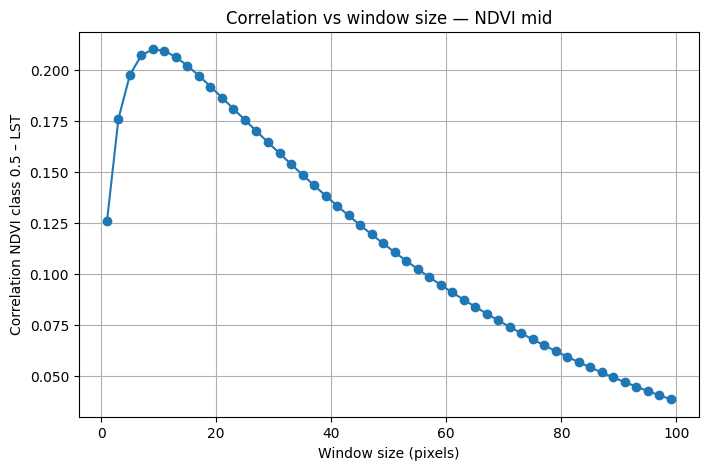

In [103]:
# Class 0.5 — mid vegetation
correlations = []

for w in window_sizes:
    ndvi_mw_path = os.path.join(output_folder_mw_ndvi, f'class_0p5_window{w}.tif')
    with rasterio.open(ndvi_mw_path) as src:
        ndvi_crop, _ = mask(src, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    valid_mask = ~np.isnan(lst_clip)
    corr = np.corrcoef(ndvi_crop[valid_mask], lst_clip[valid_mask])[0, 1]
    correlations.append(corr)

plt.figure(figsize=(8, 5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel('Window size (pixels)')
plt.ylabel('Correlation NDVI class 0.5 – LST')
plt.title('Correlation vs window size — NDVI mid')
plt.grid(True)
plt.show()

#### NDWI – LST

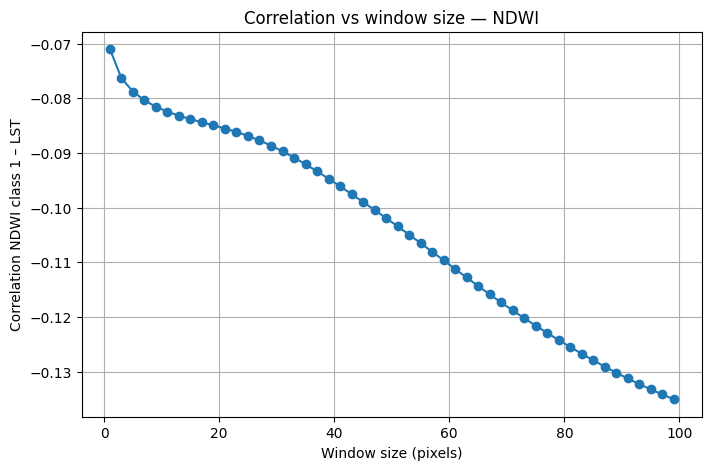

In [63]:
correlations = []

for w in window_sizes:
    ndwi_mw_path = os.path.join(output_folder_mw_ndwi, f'class_1_window{w}.tif')
    with rasterio.open(ndwi_mw_path) as src:
        gdf_ndwi = gdf.to_crs(src.crs)
        ndwi_crop, _ = mask(src, gdf_ndwi.geometry, crop=True)
        ndwi_crop = ndwi_crop[0].astype(float)

    valid_mask = ~np.isnan(lst_clip)
    corr = np.corrcoef(ndwi_crop[valid_mask], lst_clip[valid_mask])[0, 1]
    correlations.append(corr)

plt.figure(figsize=(8, 5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel('Window size (pixels)')
plt.ylabel('Correlation NDWI class 1 – LST')
plt.title('Correlation vs window size — NDWI')
plt.grid(True)
plt.show()

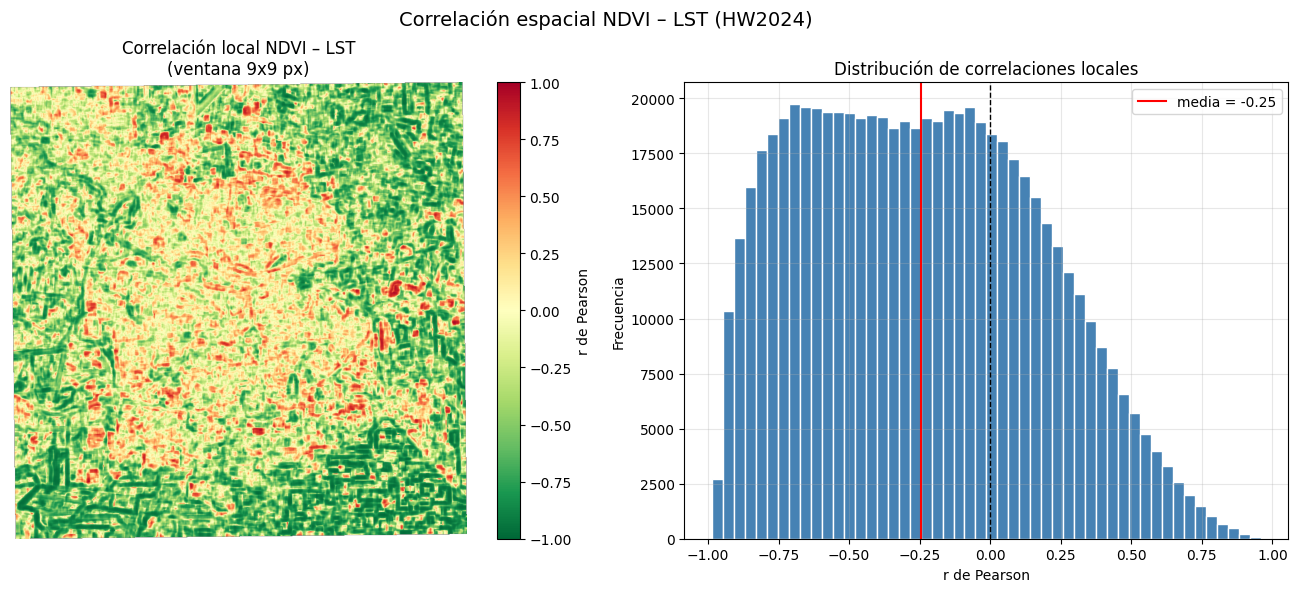

Correlación media: -0.246
% píxeles con r < -0.3 (correlación negativa fuerte): 47.4%
% píxeles con r >  0.3 (correlación positiva fuerte): 10.9%


In [70]:
# Mapa espacial de correlación local NDVI – LST
# Usa una ventana deslizante para calcular correlación píxel a píxel

from scipy.ndimage import generic_filter

def local_correlation(window_flat):
    """Correlación de Pearson entre dos mitades de la ventana aplanada."""
    n = len(window_flat) // 2
    x = window_flat[:n]
    y = window_flat[n:]
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() < 4:
        return np.nan
    return np.corrcoef(x[valid], y[valid])[0, 1]

# Elegí el tamaño de ventana local (impar)
local_window = 9  # ~21x21 píxeles, podés cambiar esto

# Cargar NDVI continuo (no clasificado) y LST clipeado
with rasterio.open(ndvi_path) as src:
    ndvi_arr = src.read(1).astype('float32')
    profile  = src.profile
    transform_ndvi = src.transform

with rasterio.open(lst_clipped_path) as src:
    lst_arr = src.read(1).astype('float32')

# Alinear shapes si difieren por 1 píxel
min_r = min(ndvi_arr.shape[0], lst_arr.shape[0])
min_c = min(ndvi_arr.shape[1], lst_arr.shape[1])
ndvi_arr = ndvi_arr[:min_r, :min_c]
lst_arr  = lst_arr[:min_r, :min_c]

# Reemplazar nan con 0 temporalmente para generic_filter (los manejamos adentro)
ndvi_nan = np.where(np.isnan(ndvi_arr), np.nan, ndvi_arr)
lst_nan  = np.where(np.isnan(lst_arr),  np.nan, lst_arr)

# Stack como array 3D para pasar ambas capas juntas al filtro
stacked = np.concatenate([ndvi_nan.ravel(), lst_nan.ravel()])

# generic_filter no soporta dos arrays directamente,
# así que lo hacemos con una sliding window manual vectorizada
from numpy.lib.stride_tricks import sliding_window_view

h, w = ndvi_arr.shape
pad  = local_window // 2

ndvi_pad = np.pad(ndvi_arr, pad, constant_values=np.nan)
lst_pad  = np.pad(lst_arr,  pad, constant_values=np.nan)

ndvi_windows = sliding_window_view(ndvi_pad, (local_window, local_window))
lst_windows  = sliding_window_view(lst_pad,  (local_window, local_window))

# Reshape para vectorizar: (n_pixels, n_window_pixels)
ndvi_w = ndvi_windows.reshape(h * w, -1)
lst_w  = lst_windows.reshape(h * w, -1)

# Correlación vectorizada píxel a píxel
local_corr = np.full(h * w, np.nan)

for i in range(h * w):
    x = ndvi_w[i]
    y = lst_w[i]
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() >= 4:
        local_corr[i] = np.corrcoef(x[valid], y[valid])[0, 1]

local_corr = local_corr.reshape(h, w)

# Enmascarar píxeles fuera de la ciudad (donde LST es nan)
local_corr[np.isnan(lst_arr)] = np.nan

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Mapa de correlación
im = axs[0].imshow(local_corr, cmap='RdYlGn_r', vmin=-1, vmax=1)
axs[0].set_title(f'Correlación local NDVI – LST\n(ventana {local_window}x{local_window} px)')
axs[0].axis('off')
plt.colorbar(im, ax=axs[0], label='r de Pearson', fraction=0.046)

# Histograma de valores de correlación
vals = local_corr[~np.isnan(local_corr)]
axs[1].hist(vals, bins=50, color='steelblue', edgecolor='white')
axs[1].axvline(0,  color='black', linestyle='--', linewidth=1)
axs[1].axvline(np.nanmean(local_corr), color='red', linestyle='-',
               linewidth=1.5, label=f'media = {np.nanmean(local_corr):.2f}')
axs[1].set_xlabel('r de Pearson')
axs[1].set_ylabel('Frecuencia')
axs[1].set_title('Distribución de correlaciones locales')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.suptitle('Correlación espacial NDVI – LST (HW2024)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Correlación media: {np.nanmean(local_corr):.3f}')
print(f'% píxeles con r < -0.3 (correlación negativa fuerte): {(vals < -0.3).mean()*100:.1f}%')
print(f'% píxeles con r >  0.3 (correlación positiva fuerte): {(vals >  0.3).mean()*100:.1f}%')